## O que é SQL Injection?

SQL Injection é um tipo de ataque cibernético em que o invasor insere comandos SQL maliciosos em campos de entrada (como formulários, URLs ou parâmetros) para manipular o banco de dados de uma aplicação.

👉 Em poucas linhas:

- O atacante “injeta” comandos SQL em entradas não protegidas.

- O banco de dados interpreta esses comandos como válidos.

- Isso pode permitir roubar dados, alterar informações, deletar tabelas ou até tomar controle do servidor.

Exemplo simples:

Entrada esperada: admin
Entrada maliciosa: admin' OR '1'='1

Se a aplicação não tratar isso corretamente, o atacante pode conseguir acesso sem senha.

Em resumo:

`SQL Injection é uma vulnerabilidade que permite manipular consultas ao banco de dados por meio de entradas maliciosas, podendo causar vazamento de dados e danos graves à aplicação.`

## ✅ Como identificar SQL Injection
1. Comportamentos suspeitos na aplicação

- Mensagens de erro SQL aparecendo na tela (ex.: syntax error, mysql_fetch, unterminated string).

- Páginas que quebram quando você coloca caracteres como ', ", --, ;, ).

2. Testes manuais simples (entrada maliciosa)

- Tente inserir valores conhecidos por causar falhas quando não tratados:

**a) Teste com aspas:**
`
'
" 
'' 
`

- Se aparecer erro SQL, é um forte indicativo.

**b) Teste com operadores lógicos:**

`
' OR 1=1 --
" OR "1"="1
`

- Se a aplicação retornar muito mais dados ou burlar autenticação, há falha.

**c) Teste de Comentarios:**

`admin' --`

- Se ignorar a senha e logar, é vulnerável.


### 📌 Resumo rápido:

Você identifica SQL Injection quando:

entradas comuns quebram a página, permitem burlar autenticação, alteram consultas, aparecem erros SQL, ou quando ferramentas detectam manipulação de queries não tratadas.

# Detectando e Previnindo Ataques de SQL Injection


Neste projeto o objetivo é construir um modelo preditivo capaz de detectar e prevenir ataques cibernéticos de SQL Injection. Por estarmos trabalhando com queries SQL como dados de  entrada,  daremos  atenção  especial  ao  pré-processamento  de  dados.  

Criaremos  diversas versões do modelo, vamos compará-las e então selecionar a que apresente melhor performance. Ao final, faremos o deploy e uso do modelo com novos dados (novas queries SQL). Usaremos  os  dados  disponíveis  no  link  abaixo:

- https://www.kaggle.com/datasets/sajid576/sql-injection-dataset

`A coluna Query contém as strings de consulta SQL brutas e a coluna Label contém o valor inteiro  0  ou  1.  Na  coluna  Label, 0 indica  consulta SQL não  maliciosa e 1 indica a consulta SQL maliciosa` (consequentemente, um possível ataque SQL Injection).

In [1]:
import pickle
import sklearn
import pandas as pd
from time import time
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [17]:
dados_sql = pd.read_csv("dados/dados_sql.csv", encoding = 'utf-8')
dados_sql.head()

,Query,Label
0,""" or pg_sleep ( __TIME__ ) --",1
1,create user name identified by pass123 tempora...,1
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1


In [18]:
dados_sql.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30919 entries, 0 to 30918
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Query   30919 non-null  object
 1   Label   30919 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 483.2+ KB


## Análise Exploratória e Limpeza dos Dados

In [4]:
# verificando se tem duplcafdas
dados_sql.duplicated(subset = ["Query", "Label"]).sum()

12

In [7]:
# Removendo-as
dados_sql.drop_duplicates(inplace = True)

In [8]:
#verifcando ausentes
dados_sql.isnull().sum()

Query    0
Label    0
dtype: int64

In [10]:
dados_sql.Label.value_counts()

Label
0    19529
1    11378
Name: count, dtype: int64

In [11]:
print(f"Queries SQL Seguras: {dados_sql['Label'].value_counts()[0]}")
print(f"Queries SQL Maliciosas: {dados_sql['Label'].value_counts()[1]}")
print(f"Shape do Dataset: {dados_sql.shape}")

Queries SQL Seguras: 19529
Queries SQL Maliciosas: 11378
Shape do Dataset: (30907, 2)


### Pré-Processamento (Vetorização)

Precisamos vetorizar pois temos dados de texto no dataset

In [42]:
# separando x e y

X = dados_sql['Query']
y = dados_sql['Label']

# dividindo em treino e teste

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.3, random_state = 1) 

`TfidfVectorizer()` usado abaixo, é uma classe da biblioteca scikit-learn usada para converter uma coleção de documentos de texto brutos em uma matriz de recursos TF-IDF.

Aqui está uma explicação mais detalhada dos componentes:

**TF (Term Frequency)**: É a frequência de uma palavra em um documento. Se uma palavra ocorrer frequentemente em um documento, seu valor de term frequency será alto.

**IDF (Inverse Document Frequency)**: É o inverso da frequência de documentos que contêm a palavra específica. Se uma palavra ocorrer em muitos documentos, seu valor IDF será baixo; se ocorrer em poucos documentos, o valor será alto. Isso ajuda a dar mais peso às palavras que são mais exclusivas para um documento específico, ao mesmo tempo em que reduz o peso de palavras comuns (como "o", "é", "em", etc.) que não acrescentam muito valor informativo.

A combinação de TF e IDF (TF-IDF) permite que as palavras sejam ponderadas de acordo com o quão importantes elas são para um documento específico em um conjunto de documentos.

TfidfVectorizer() faz todo o processo de calcular TF, IDF e converter os documentos em uma matriz TF-IDF.

In [43]:
vectorizer = TfidfVectorizer()

X_treino = vectorizer.fit_transform(X_treino)
X_teste = vectorizer.transform(X_teste)

In [44]:
X_treino.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [45]:
X_teste.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [46]:
vectorizer.get_feature_names_out()

array(['00', '000001', '000003', ..., 'zzkx', 'ã½', '트리거'], dtype=object)

## Modelagem Preditiva

Vamos construir 6 versões do modelo de Machine Learning usando 6 diferentes algoritmos. Ao final, vamos compará-las e então selecionar a melhor versão do modelo.

#### Fórmulas das Métricas de Avaliação dos Modelos:

> accuracy = (TP + TN) / (TP + TN + FP + FN)

> Precision = TP / (TP + FP)

> Recall = TP / (TP + FN)

> F1-score = 2 * (Precision * Recall) / (Precision + Recall)

In [50]:
# funcao para calculo das metricas

def avalia_modelo(model_pred, model_name:str, y_test = y_teste):
    confusion = confusion_matrix(y_test, model_pred)

    TP = confusion[1,1] #true positive
    TN = confusion[0,0] # true negatives
    FP = confusion[1,0] #false positives
    FN = confusion[0,1] #false negative

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1_score = 2 * (precision * recall) / (precision + recall)

    print(f"Avaliação do Modelo de {model_name}")
    print("--------------------------------------")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1-score: {f1_score}")
    print("--------------------------------------")

### Versão 1 do Modelo - Regressão Logística

A regressão logística é um algoritmo de aprendizado supervisionado usado para problemas de classificação. É um algoritmo estatístico que visa prever a probabilidade de um evento ocorrer, dada uma série de variáveis de entrada, produzindo um valor entre 0 e 1.

Aqui estão alguns pontos-chave sobre a regressão logística:

**Classificação binária**: A regressão logística é usada principalmente para classificação binária, onde o resultado alvo tem dois possíveis estados (como 0/1, verdadeiro/falso, sucesso/falha). No entanto, também pode ser adaptada para problemas de classificação multiclasse.

**Probabilidade de evento**: A regressão logística estima a probabilidade de uma instância específica pertencer a uma classe específica.

**Função logística**: A regressão logística usa uma função logística para transformar sua saída e garantir que ela esteja entre 0 e 1. Isso é feito aplicando a função logística (também conhecida como função sigmóide) à combinação linear das características de entrada.

**Estimação de coeficientes**: O algoritmo usa o método de máxima verossimilhança para estimar os coeficientes que maximizam a probabilidade dos dados observados.

**Interpretabilidade**: Os coeficientes em uma regressão logística podem ser interpretados em termos de chances (odds ratios), o que torna este método útil em campos como medicina e ciências sociais.

**Regularização**: A regressão logística pode incluir a regularização L1 (Lasso) ou L2 (Ridge) para ajudar a prevenir o sobreajuste, tornando alguns coeficientes de características zero (Lasso) ou reduzindo a magnitude dos coeficientes (Ridge).

**Limitações**: A regressão logística assume que há uma relação linear entre as características de entrada e o logaritmo da chance. Se essa suposição não for verdadeira, o modelo pode ter um desempenho ruim. Além disso, a regressão logística pode não funcionar bem quando as características de entrada são altamente correlacionadas ou quando há interações complexas entre as características.

In [51]:
modelo_v1_lr = LogisticRegression()

modelo_v1_lr.fit(X_treino, y_treino)

v1_lr_pred = modelo_v1_lr.predict(X_teste)

avalia_modelo(v1_lr_pred, "Regressao Logistica")

Avaliação do Modelo de Regressao Logistica
--------------------------------------
Accuracy: 0.9692755498059509
Precision: 0.9293276108726752
Recall: 0.9884357881923311
F1-score: 0.9579708007668486
--------------------------------------


### Versão 2 do Modelo - Árvore de Decisão

Uma árvore de decisão é um algoritmo de aprendizado supervisionado usado tanto para problemas de classificação quanto de regressão. Ela funciona dividindo os dados em subconjuntos com base em diferentes valores de atributos. Isso é realizado através de uma estrutura de árvore hierárquica que modela decisões e suas possíveis consequências.

Aqui estão alguns pontos-chave sobre árvores de decisão:

**Divisões baseadas em atributos**: Uma árvore de decisão faz divisões binárias nos dados. Cada nó na árvore representa uma decisão baseada em um atributo, dividindo os dados em dois ramos com base nessa decisão.

**Folhas representam previsões**: As folhas da árvore representam as previsões, que são a média do valor alvo (em caso de regressão) ou a classe mais comum (em caso de classificação) dos exemplos naquela folha.

**Estrutura de árvore**: As árvores de decisão são fáceis de entender e visualizar, já que podem ser desenhadas como uma árvore e seguidas desde a raiz até uma folha para fazer uma previsão.
<!-- Projeto Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->
**Importância dos atributos**: As árvores de decisão fornecem insights sobre a importância dos atributos, uma vez que os atributos usados nas divisões superiores da árvore contribuem mais para a decisão final do que os utilizados mais abaixo na árvore.

**Não linear**: As árvores de decisão podem modelar relacionamentos não lineares e interações entre atributos.

**Sobreajuste**: As árvores de decisão são propensas ao sobreajuste, especialmente se a árvore for permitida a crescer de maneira irrestrita. Isso pode ser controlado por meio de técnicas como poda, definindo a profundidade máxima da árvore ou definindo o número mínimo de amostras por folha.

**Insensível à escala**: As árvores de decisão não exigem que os dados sejam normalizados ou escalonados e são insensíveis à distribuição dos dados.

**Limitações**: As árvores de decisão podem ser instáveis, ou seja, pequenas mudanças nos dados podem resultar em árvores de decisão significativamente diferentes. Além disso, elas podem ter um desempenho ruim se a fronteira de decisão é diagonal ou envolve combinações complexas de atributos.

In [52]:
modelo_v2_dt = DecisionTreeClassifier()

modelo_v2_dt.fit(X_treino, y_treino)

v2_dt_pred = modelo_v2_dt.predict(X_teste)

avalia_modelo(v2_dt_pred, "Árvore de Decisão")

Avaliação do Modelo de Árvore de Decisão
--------------------------------------
Accuracy: 0.7986200948684777
Precision: 0.9733905579399141
Recall: 0.6571373382267722
F1-score: 0.7845940959409593
--------------------------------------


### Versão 3 do Modelo - Random Forest

Random Forest é um algoritmo de aprendizado de máquina supervisionado utilizado tanto para tarefas de classificação quanto de regressão. Ele é conhecido como um "ensemble learning method", pois combina várias árvores de decisão para produzir uma previsão mais precisa e robusta.

Aqui estão alguns pontos-chave sobre Random Forest:

**Ensemble de Árvores de Decisão**: Um Random Forest é composto por um conjunto (ou "floresta") de árvores de decisão individuais, cada uma treinada em uma amostra aleatória dos dados. A amostra é selecionada com substituição, um processo conhecido como "bootstrap".

**Diversidade através de Randomização**: Cada árvore na floresta é única através do uso de seleção aleatória de recursos para cada divisão ao construir a árvore. Isso cria diversidade nas árvores e ajuda a evitar o sobreajuste.

**Votação de árvores**: Para fazer uma previsão, o Random Forest faz com que cada uma de suas árvores de decisão faça uma previsão individualmente. No caso da classificação, a classe que recebe a maioria dos votos é a previsão do Random Forest. No caso da regressão, a média das previsões das árvores é tomada.

**Avaliação do desempenho**: O Random Forest tem uma maneira incorporada de avaliar seu desempenho chamada "out-of-bag" (OOB) score. Cada árvore é treinada em uma amostra bootstrap dos dados e a previsão é testada nas observações não incluídas nessa amostra (o "out-of-bag" sample).

**Importância do recurso**: Random Forest é capaz de medir a importância dos recursos observando quanto a perda de precisão ocorre quando os valores de um recurso são permutados aleatoriamente. Recursos mais importantes resultarão em uma maior perda de precisão.

**Modelagem não linear e interações**: Random Forest é capaz de modelar relacionamentos não lineares e capturar interações entre recursos.

**Robustez e facilidade de uso**: Random Forest é conhecido por sua robustez e geralmente produz bons resultados, mesmo sem a sintonização fina de parâmetros. Ele também lida bem com dados faltantes e não é muito afetado por outliers.

**Limitações**: Random Forest pode ser computacionalmente intensivo e lento para prever se o número de árvores é grande. Além disso, enquanto Random Forest é capaz de lidar com dados categóricos, ele pode ter dificuldade com categorias com muitos níveis.

In [53]:
modelo_v3_rf = RandomForestClassifier()

modelo_v3_rf.fit(X_treino, y_treino)

v3_rf_pred = modelo_v3_rf.predict(X_teste)

avalia_modelo(v3_rf_pred, "Random Forest")

Avaliação do Modelo de Random Forest
--------------------------------------
Accuracy: 0.8004527813712807
Precision: 0.9948497854077253
Recall: 0.6548022598870057
F1-score: 0.789778534923339
--------------------------------------


### Versão 4 do Modelo - Support Vector Machines
As Máquinas de Vetores de Suporte (Support Vector Machines, SVM) são um conjunto de métodos de aprendizado supervisionado usados para classificação e regressão. Em particular, eles são altamente eficazes em problemas de classificação binária. O principal objetivo do SVM é encontrar um hiperplano de separação ótimo que maximiza a margem entre as classes em um espaço de recursos.

Aqui estão alguns pontos-chave sobre o SVM:

**Hiperplano de separação**: O SVM busca um hiperplano que separa as classes de dados com a maior margem possível. O hiperplano é escolhido para maximizar a distância dos exemplos de treinamento mais próximos de cada classe, conhecidos como "vetores de suporte".

**Maximização da Margem**: O objetivo de maximizar a margem proporciona alguma robustez à classificação e ajuda a prevenir o sobreajuste, fazendo do SVM um classificador robusto.

**Kernel Trick**: Para dados que não são linearmente separáveis, o SVM usa uma técnica conhecida como "kernel trick" para projetar os dados em um espaço de maior dimensão onde eles se tornam linearmente separáveis. Isso permite que o SVM modele relações complexas e não lineares.

**Classificação e Regressão**: Embora o SVM seja mais conhecido por classificação, ele também pode ser usado para regressão (Support Vector Regression, SVR) e outras tarefas, como detecção de outliers.

**Regularização**: O SVM inclui um parâmetro de regularização 'C' que permite ao usuário especificar a quantidade de erros de classificação e a largura da margem, ajudando a evitar o sobreajuste.

**Limitações**: As SVMs podem ser sensíveis à escolha do kernel e aos parâmetros do kernel. Além disso, elas podem ser computacionalmente intensivas e menos escaláveis para conjuntos de dados de grande dimensão ou com grande quantidade de recursos. SVMs também fornecem previsões binárias em vez de probabilidades.

**Necessidade de Pré-processamento**: Os dados para SVM precisam ser pré-processados, pois o algoritmo é sensível à escala das características. Normalmente, os dados são normalizados antes de serem usados no SVM.

In [54]:
modelo_v4_svm = SVC()

modelo_v4_svm.fit(X_treino, y_treino)

v4_svm_pred = modelo_v4_svm.predict(X_teste)

avalia_modelo(v4_svm_pred, "Support Vector Machines")

Avaliação do Modelo de Support Vector Machines
--------------------------------------
Accuracy: 0.8226606295817163
Precision: 0.9690987124463519
Recall: 0.6878554021121039
F1-score: 0.8046086233519419
--------------------------------------


### Versão 5 do Modelo - Multinomial Naive Bayes

Multinomial Naive Bayes é um algoritmo de aprendizado de máquina supervisionado baseado na aplicação do teorema de Bayes com a suposição de "naividade", ou seja, supondo independência entre cada par de recursos. `Esta variante do Naive Bayes é mais adequada para dados que podem ser facilmente transformados em contagens, como contagens de palavras em textos.`

Aqui estão alguns pontos-chave sobre o Multinomial Naive Bayes:

**Teorema de Bayes**: A base do Multinomial Naive Bayes é o teorema de Bayes, que descreve a probabilidade de um evento com base em conhecimentos anteriores relevantes.

**Independência de recursos**: O Naive Bayes assume que todos os recursos são mutuamente independentes. Na prática, essa suposição raramente é válida, mas o algoritmo ainda tende a funcionar bem.

**Dados de contagem**: Multinomial Naive Bayes é particularmente útil para dados que representam contagens ou frequências, como contagem de palavras em documentos de texto.

**Aprendizado e previsão rápidos**: Devido à sua simplicidade e suposição de independência de recursos, o Multinomial Naive Bayes é rápido para treinar e fazer previsões.

**Uso comum em classificação de texto**: Um uso comum do Multinomial Naive Bayes é na classificação de texto, onde os recursos são palavras e os dados são contagens ou frequências dessas palavras em documentos.

**Suavização de Laplace**: Para lidar com recursos que não aparecem no conjunto de treinamento e evitar probabilidades zero, o Multinomial Naive Bayes usa uma técnica conhecida como suavização de Laplace ou adição de um.

**Limitações**: Embora seja rápido e frequentemente surpreendentemente preciso, o Multinomial Naive Bayes pode ser superado por modelos mais complexos em tarefas que violam fortemente a suposição de independência de recursos. Além disso, não funciona bem com contagens de recursos muito grandes ou contínuas.

modelo_v5_nb = MultinomialNB()

modelo_v5_nb.fit(X_treino, y_treino)

v5_nb_pred = modelo_v5_nb.predict(X_teste)

avalia_modelo(v5_nb_pred, "Multinomial Naive Bayes")

### Versão 6 do Modelo - Gradient Boosting

O Gradient Boosting é um poderoso algoritmo de aprendizado de máquina supervisionado usado principalmente para tarefas de regressão e classificação. É um método de "ensemble learning" que constrói um modelo preditivo de maneira aditiva e iterativa, buscando reduzir continuamente o erro residual da previsão.

Aqui estão alguns pontos-chave sobre o Gradient Boosting:

**Ensemble de Aprendizes Fracos**: O Gradient Boosting constrói um conjunto de "aprendizes fracos" (geralmente árvores de decisão), onde cada aprendiz é treinado para corrigir os erros feitos pelos aprendizes anteriores.

**Modelo Aditivo**: Cada novo aprendiz é adicionado ao modelo de forma a minimizar a função de perda global. A ideia é que, à medida que mais e mais aprendizes são adicionados, o modelo se torna cada vez mais preciso.

**Descida de Gradiente**: A técnica de otimização usada para minimizar a função de perda é a descida de gradiente, daí o nome "Gradient Boosting". Basicamente, em cada etapa, o algoritmo ajusta o modelo na direção que reduzirá mais rapidamente a função de perda.

**Regularização**: O Gradient Boosting inclui vários mecanismos de regularização para prevenir o sobreajuste, como a adição de uma penalidade de complexidade de modelo no critério de otimização e o uso de uma taxa de aprendizado (também conhecida como "shrinkage" ou "learning rate").

**Manipulação de Dados Variados**: O Gradient Boosting pode manipular dados com características mistas (numéricas e categóricas) e não é afetado por características irrelevantes ou escalas de características variadas.

**Performance**: O Gradient Boosting é conhecido por sua alta performance e é frequentemente o algoritmo de escolha em competições de aprendizado de máquina.

**Desvantagens**: A principal desvantagem do Gradient Boosting é que ele pode ser computacionalmente intensivo e requer cuidadosa sintonia dos hiperparâmetros. Além disso, devido à sua natureza sequencial, pode ser mais difícil de paralelizar do que outros algoritmos de "ensemble learning", como o Random Forest.

In [56]:
modelo_v6_gb = GradientBoostingClassifier(n_estimators = 20, 
                                          learning_rate = 0.8, 
                                          max_features = 2, 
                                          max_depth = 2, 
                                          random_state = 0)

modelo_v6_gb.fit(X_treino, y_treino)

v6_gb_pred = modelo_v6_gb.predict(X_teste)

avalia_modelo(v6_gb_pred, "Gradient Boosting")

Avaliação do Modelo de Gradient Boosting
--------------------------------------
Accuracy: 0.6234368262181975
Precision: 0.0008583690987124463
Recall: 0.75
F1-score: 0.0017147756501857672
--------------------------------------


## Comparação e Seleção do Melhor Modelo

In [57]:
# Dicionários para as métricas
f1_dict = {}
precision_dict = {}
recall_dict = {}
accuracy_dict = {}

In [58]:
# Atualiza o dicionário de métricas para cada modelo

f1_dict["LogisticRegression"] = f1_score(v1_lr_pred, y_teste)
precision_dict["LogisticRegression"] = precision_score(v1_lr_pred, y_teste)
recall_dict["LogisticRegression"] = recall_score(v1_lr_pred, y_teste)
accuracy_dict['LogisticRegression'] = accuracy_score(v1_lr_pred, y_teste)

f1_dict["DecisionTree"] = f1_score(v2_dt_pred, y_teste)
precision_dict["DecisionTree"] = precision_score(v2_dt_pred, y_teste)
recall_dict["DecisionTree"] = recall_score(v2_dt_pred, y_teste)
accuracy_dict['DecisionTree'] = accuracy_score(v2_dt_pred, y_teste)

f1_dict["RandomForest"] = f1_score(v3_rf_pred, y_teste)
precision_dict["RandomForest"] = precision_score(v3_rf_pred, y_teste)
recall_dict["RandomForest"] = recall_score(v3_rf_pred, y_teste)
accuracy_dict['RandomForest'] = accuracy_score(v3_rf_pred, y_teste)

f1_dict["SVM"] = f1_score(v4_svm_pred, y_teste)
precision_dict["SVM"] = precision_score(v4_svm_pred, y_teste)
recall_dict["SVM"] = recall_score(v4_svm_pred, y_teste)
accuracy_dict['SVM'] = accuracy_score(v4_svm_pred, y_teste)

f1_dict["NaiveBayes"] = f1_score(v5_nb_pred, y_teste)
precision_dict["NaiveBayes"] = precision_score(v5_nb_pred, y_teste)
recall_dict["NaiveBayes"] = recall_score(v5_nb_pred, y_teste)
accuracy_dict['NaiveBayes'] = accuracy_score(v5_nb_pred, y_teste)

f1_dict["GradientBoosting"] = f1_score(v6_gb_pred, y_teste)
precision_dict["GradientBoosting"] = precision_score(v6_gb_pred, y_teste)
recall_dict["GradientBoosting"] = recall_score(v6_gb_pred, y_teste)
accuracy_dict['GradientBoosting'] = accuracy_score(v6_gb_pred, y_teste)

In [59]:
# Os nomes das chaves serão os nomes dos dicionários
chaves = f1_dict, precision_dict, recall_dict, accuracy_dict

# Métricas
metricas = ['F1_Score', 'Precision', 'Recall', 'Accuracy']

# Dataframe
tabela_metricas = pd.DataFrame(chaves)

# Índice
tabela_metricas.index = metricas

# Tabela de métricas
tabela_metricas

,LogisticRegression,DecisionTree,RandomForest,SVM,NaiveBayes,GradientBoosting
F1_Score,0.957971,0.784594,0.789779,0.804609,0.955228,0.001715
Precision,0.929328,0.973391,0.994850,0.969099,0.937053,0.000858
Recall,0.988436,0.657137,0.654802,0.687855,0.974123,0.750000
Accuracy,0.969276,0.798620,0.800453,0.822661,0.966904,0.623437


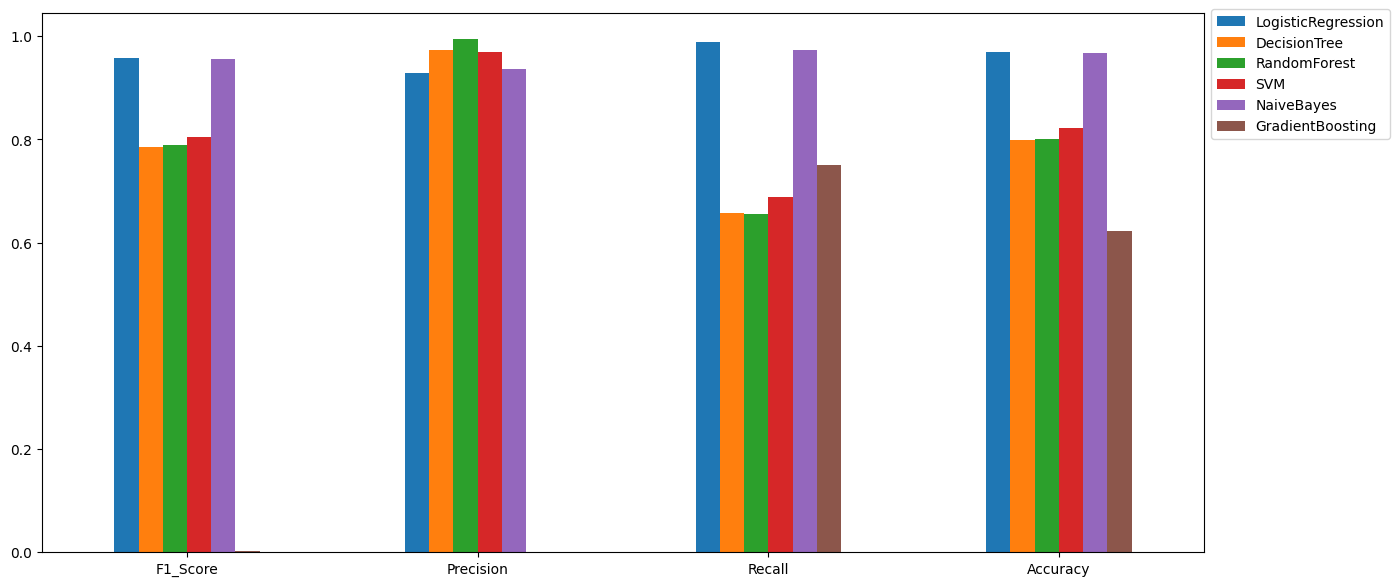

In [60]:
# Gráfico da tabela de métricas
resultado = tabela_metricas.plot(kind = 'bar', rot = 0, figsize = (15, 7))
resultado.legend(bbox_to_anchor = (1, 1.02), loc = 'upper left');

Com base nas métricas, o modelo que eu escolheria para fazer o deploy seria a **Logistic Regression.**

Justificativa:

- F1-Score: Tem o F1-Score mais alto (0.962), o que indica um bom equilíbrio entre precisão e recall. O F1-Score é especialmente importante quando há uma necessidade de equilibrar tanto a precisão quanto o recall, para evitar falsos negativos e falsos positivos de forma proporcional.

- Precision: A precisão é alta (0.937), o que significa que a maioria das previsões positivas do modelo está correta.

- Recall: Apresenta um recall elevado (0.989), sugerindo que o modelo consegue identificar bem as ocorrências positivas.

- Accuracy: Tem a maior acurácia (0.972), o que significa que a maioria das previsões gerais (positivas e negativas) está correta.

Comparação com Naie Bayes:

- Naive Bayes tem um F1-Score próximo (0.957), mas apresenta uma precisão um pouco menor e, dependendo do contexto, pode ser menos robusto do que a regressão logística.

Portanto, a Logistic Regression seria a escolha mais robusta e confiável para deploy, considerando as métricas apresentadas. Na maioria dos casos o que buscamos é um modelo equilibrado.

In [61]:
with open('modelos/vectorizer', 'wb') as fin:
    pickle.dump(vectorizer, fin)

In [62]:
pickle.dump(modelo_v1_lr, open("modelos/melhor_modelo.pkl", "wb"))

## Testando modelo em novas tentativas de ataque SQL Injection

In [63]:
vetorizador_final = pickle.load(open("modelos/vectorizer", 'rb'))
modelo_final = pickle.load(open("modelos/melhor_modelo.pkl", "rb"))

In [64]:
with open("dados/novos_dados_sql.txt", "r") as file:
    lines = file.readlines()


novos_dados = pd.DataFrame(lines, columns = ['Query'])
novos_dados = novos_dados.replace("\n", "", regex = True)
novos_dados

,Query
0,"'UNION SELECT user, password FROM users#"
1,"1 or 1=1 UNION SELECT user, password FROM users#"
2,"1'UNION SELECT user, password FROM users#"
3,1 or sleep(4)#
4,"1' benchmark(10000000,MD5(1))#"
5,5--
6,"SELECT username, password FROM users"


In [65]:
# Aplica o vetorizador
sql_query = vetorizador_final.transform(novos_dados['Query'])

# Faz a previsão
resultados = modelo_final.predict(sql_query)
resultados

array([1, 1, 1, 1, 1, 0, 0])

In [66]:
# Inicializa os contadores
count_malicious = 0
count_safe = 0

In [67]:
# Loop
print("Previsões do Modelo:\n")
for resultado in resultados:
    if resultado == 1:
        count_malicious = count_malicious + 1
        print("1")
    else:
        count_safe = count_safe + 1
        print("0")

Previsões do Modelo:

1
1
1
1
1
0
0


In [68]:
# Instrução SQL
input_val = "1, ( select  ( case when  ( 1609 = 1609 )  then waitfor delay '0:0:5' else 1609* ( select 1609 from master..sysdatabases )  end  )  )  "

In [69]:
# Prepara a lista
input_val = [input_val]

# Aplica o vetorizador
input_val = vetorizador_final.transform(input_val).toarray()

# Faz a previsão
resultado = modelo_final.predict(input_val)

In [70]:
if resultado == 0:
    print("A Query Provavelmente é Segura!")
elif resultado == 1:
    print("A Query Provavelmente é Maliciosa! Pode Ser um Ataque de SQL Injection!")
else:
    print("Valor inválido")

A Query Provavelmente é Maliciosa! Pode Ser um Ataque de SQL Injection!
